# model Decision
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [183]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.naive_bayes import GaussianNB as GNB
from sklearn.tree import DecisionTreeClassifier as DT
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import keras
from keras import layers
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, classification_report, roc_curve, precision_score, recall_score, f1_score, roc_auc_score, auc
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import warnings
from sklearn.preprocessing import label_binarize
from sklearn.discriminant_analysis import StandardScaler


--------------------------

## helpfull code

In [184]:
def evaluate_model_metrics(model, model_name,
                           x_train, y_train,
                           x_test, y_test):

    y_pred_train = model.predict(x_train)
    y_pred_test  = model.predict(x_test)

    report_dict = classification_report(
        y_test,
        y_pred_test,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T

    report_df = report_df.loc[
        [str(c) for c in sorted(y_test.unique())] +
        ["accuracy"]
    ]


    display(         
        report_df.style
            .format("{:.2%}")
            .set_caption(f"{model_name} Classification Report")
    )



In [185]:
def plot_confusion_matrices(model, model_name,
                            x_train, y_train,
                            x_test, y_test):

    y_pred_train = model.predict(x_train)
    y_pred_test  = model.predict(x_test)

    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test  = confusion_matrix(y_test, y_pred_test)

    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{model_name} - Train")

    ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f"{model_name} - Test")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_roc_curve(model, model_name, x_test, y_test):

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_test)
    else:
        raise ValueError(f"{model_name} does not support predict_proba or decision_function.")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], "--")  # baseline random
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [286]:
def plot_feature_transport_pies(df, feature_col, target_col="Transported"):

    fig, axes = plt.subplots(1, 3, figsize=(16,5))

    # ---------- Pie 1 ----------
    data1 = df[df[feature_col] == 1][target_col].value_counts().sort_index()
    axes[0].pie(
        data1,
        labels=["Not Transported", "Transported"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[0].set_title(f"{feature_col}=1 → Transported")

    # ---------- Pie 2 ----------
    data2 = df[df[feature_col] == 0][target_col].value_counts().sort_index()
    axes[1].pie(
        data2,
        labels=["Not Transported", "Transported"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[1].set_title(f"{feature_col}=0 → Transported")

    # ---------- Pie 3 ----------
    data3 = df[df[target_col] == 1][feature_col].value_counts().sort_index()
    axes[2].pie(
        data3,
        labels=[f"{feature_col}=0", f"{feature_col}=1"],
        autopct="%1.1f%%",
        startangle=90
    )
    axes[2].set_title(f"Among Transported → {feature_col}")

    plt.tight_layout()
    plt.show()


------------------------------------


## Load Data

In [187]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [282]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported"])
x_copy = x.copy()

## Train-Test Split

In [189]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

## Scaling

In [190]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

## הרצת מודלים שנבחנו:

### שמירת תוצאות 

In [191]:
results = []

### KNN

#### בנייה

In [192]:
knn = KNN(
    n_neighbors=43,
    metric="euclidean",
    weights="uniform"
)

knn.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=43)

#### דיוק אימון ומבחן

In [193]:
y_pred_train_knn = knn.predict(x_train)
train_acc_knn = accuracy_score(y_train, y_pred_train_knn)

y_pred_test_knn = knn.predict(x_test)
test_acc_knn = accuracy_score(y_test, y_pred_test_knn)

In [194]:
print("="*40)
print("BEST KNN — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_knn*100:.2f}%")
print("="*40)

print("="*40)
print("BEST KNN — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_knn*100:.2f}%")
print("="*40)

BEST KNN — TRAIN SET PERFORMANCE
Accuracy : 79.16%
BEST KNN — TEST SET PERFORMANCE
Accuracy : 77.63%


#### Confusion matrix

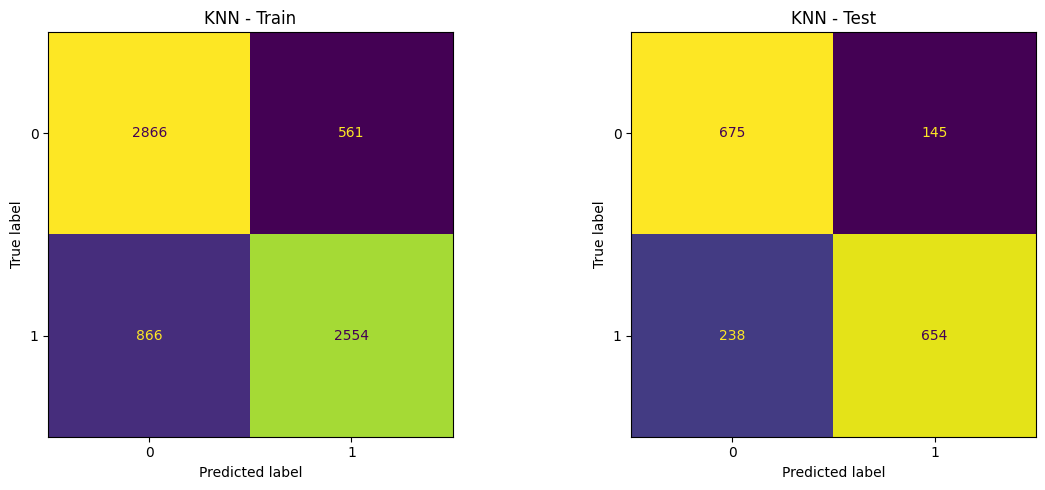

In [195]:
plot_confusion_matrices(knn, "KNN", x_train, y_train, x_test, y_test)

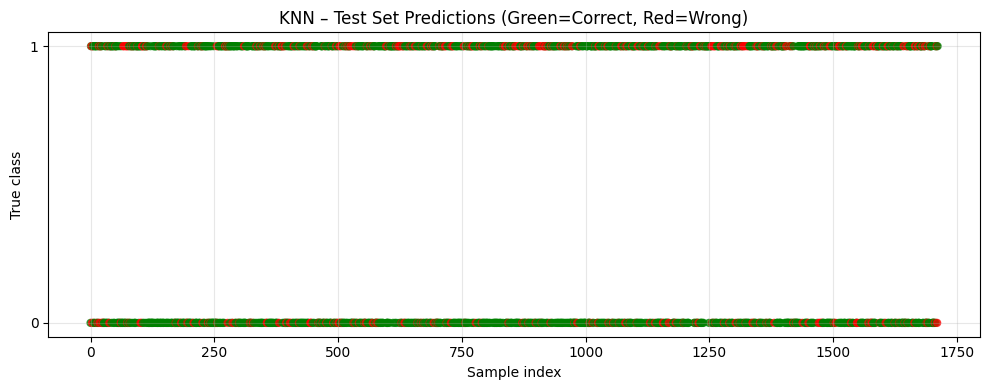

KNN Test Accuracy: 77.63%
Errors: 383 / 1712


In [196]:
correct = (y_pred_test_knn == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("KNN – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"KNN Test Accuracy: {100*test_acc_knn:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [197]:
evaluate_model_metrics(knn, "KNN", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,73.93%,82.32%,77.90%,82000.00%
1,81.85%,73.32%,77.35%,89200.00%
accuracy,77.63%,77.63%,77.63%,77.63%


#### roc curve

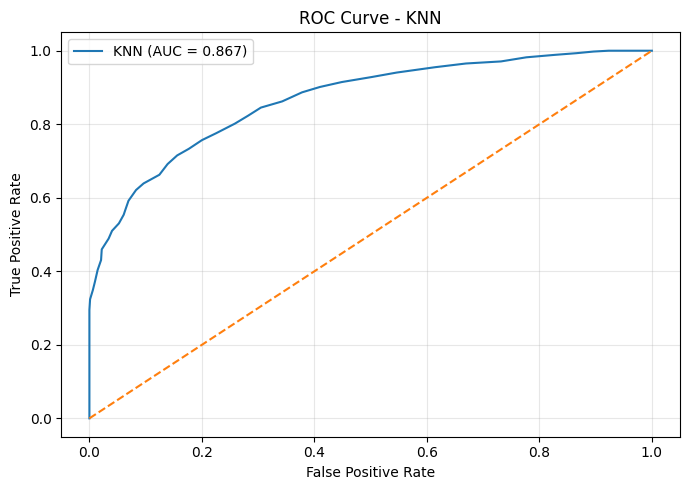

In [198]:
auc_val = plot_roc_curve(knn, "KNN", x_test, y_test)

שמירה

In [199]:
results.append({
    "Model": "KNN",
    "Train Accuracy": train_acc_knn,
    "Test Accuracy": test_acc_knn
})

--------------------------------------------

### QDA

#### בנייה

In [200]:
qda = QDA()
qda.fit(x_train, y_train)

c:\Users\Liad M\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\Liad M\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


QuadraticDiscriminantAnalysis()

#### דיוק אימון ומבחן

In [201]:
y_pred_train_qda = qda.predict(x_train)
train_acc_qda = accuracy_score(y_train, y_pred_train_qda)

y_pred_test_qda = qda.predict(x_test)
test_acc_qda = accuracy_score(y_test, y_pred_test_qda)

In [202]:
print("="*40)
print("BEST QDA — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_qda*100:.2f}%")
print("="*40)

print("="*40)
print("BEST QDA — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_qda*100:.2f}%")
print("="*40)

BEST QDA — TRAIN SET PERFORMANCE
Accuracy : 76.57%
BEST QDA — TEST SET PERFORMANCE
Accuracy : 76.52%


#### Confusion matrix

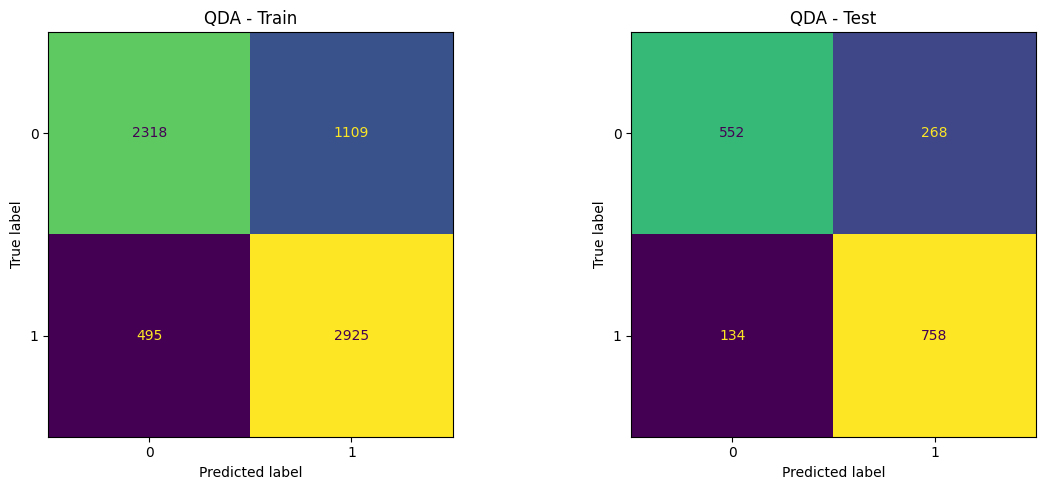

In [203]:
plot_confusion_matrices(qda, "QDA", x_train, y_train, x_test, y_test)

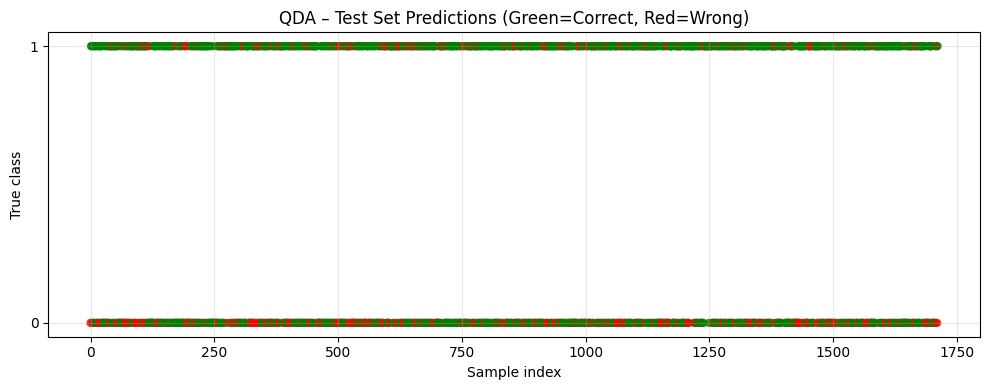

QDA Test Accuracy: 76.52%
Errors: 402 / 1712


In [204]:
correct = (y_pred_test_qda == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("QDA – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"QDA Test Accuracy: {100*test_acc_qda:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [205]:
evaluate_model_metrics(qda, "QDA", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,80.47%,67.32%,73.31%,82000.00%
1,73.88%,84.98%,79.04%,89200.00%
accuracy,76.52%,76.52%,76.52%,76.52%


#### roc curve

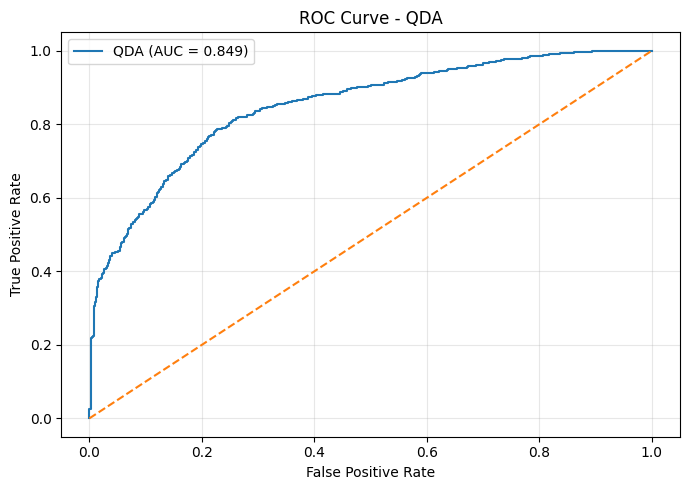

In [206]:
auc_val = plot_roc_curve(qda, "QDA", x_test, y_test)

שמירה

In [207]:
results.append({
    "Model": "QDA",
    "Train Accuracy": train_acc_qda,
    "Test Accuracy": test_acc_qda
})

---------------------------------

### LDA

#### בנייה

In [208]:
lda = LDA()
lda.fit(x_train, y_train)

LinearDiscriminantAnalysis()

#### דיוק אימון ומבחן

In [209]:
y_pred_train_lda = lda.predict(x_train)
train_acc_lda = accuracy_score(y_train, y_pred_train_lda)

y_pred_test_lda = lda.predict(x_test)
test_acc_lda = accuracy_score(y_test, y_pred_test_lda)

In [210]:
print("="*40)
print("BEST LDA — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_lda*100:.2f}%")
print("="*40)

print("="*40)
print("BEST LDA — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_lda*100:.2f}%")
print("="*40)

BEST LDA — TRAIN SET PERFORMANCE
Accuracy : 76.92%
BEST LDA — TEST SET PERFORMANCE
Accuracy : 76.64%


#### Confusion matrix

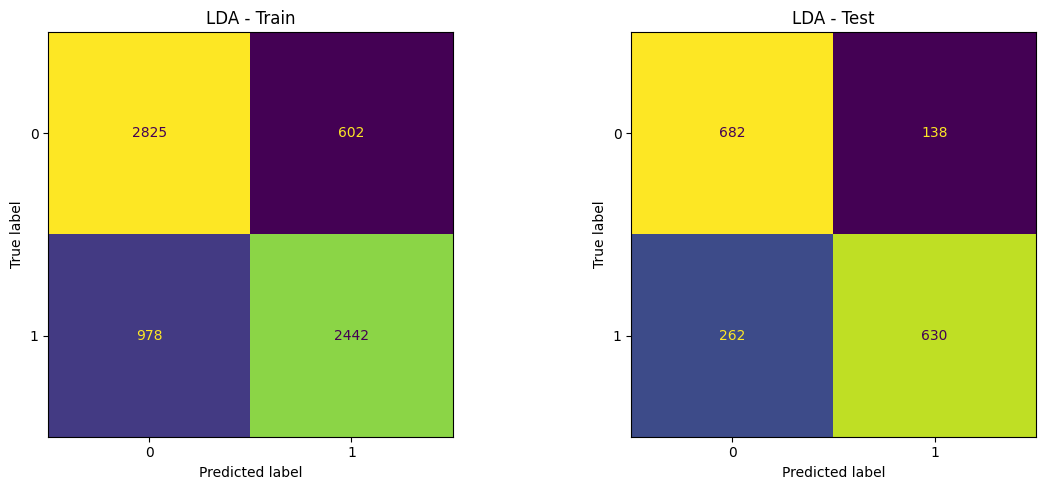

In [211]:
plot_confusion_matrices(lda, "LDA", x_train, y_train, x_test, y_test)

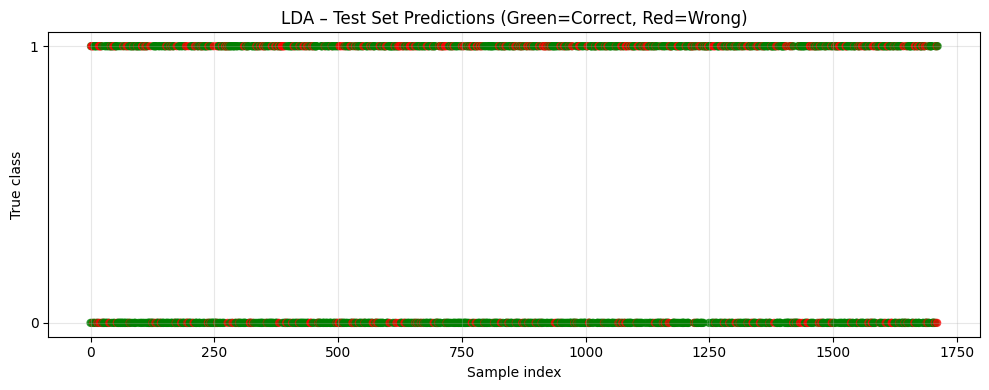

LDA Test Accuracy: 76.64%
Errors: 400 / 1712


In [212]:
correct = (y_pred_test_lda == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("LDA – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"LDA Test Accuracy: {100*test_acc_lda:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [213]:
evaluate_model_metrics(lda, "LDA", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,72.25%,83.17%,77.32%,82000.00%
1,82.03%,70.63%,75.90%,89200.00%
accuracy,76.64%,76.64%,76.64%,76.64%


#### roc curve

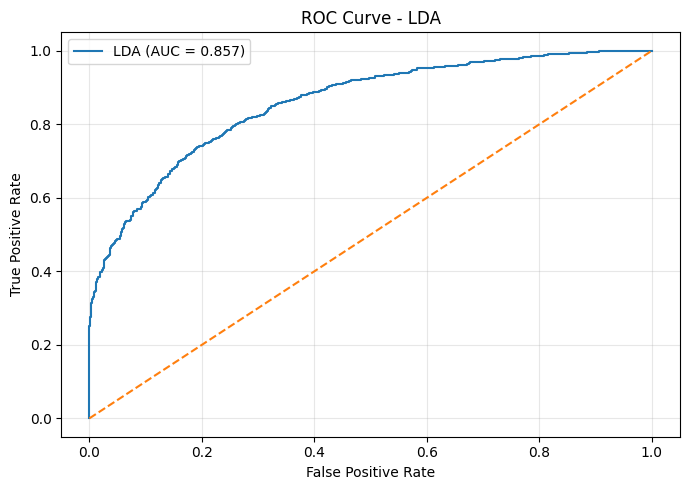

In [214]:
auc_val = plot_roc_curve(lda, "LDA", x_test, y_test)

שמירה

In [215]:
results.append({
    "Model": "LDA",
    "Train Accuracy": train_acc_lda,
    "Test Accuracy": test_acc_lda
})

-----------------------------------

### GNB

#### בנייה

In [216]:
gnb = GNB()
gnb.fit(x_train, y_train)

GaussianNB()

#### דיוק אימון ומבחן

In [217]:
y_pred_train_gnb = gnb.predict(x_train)
train_acc_gnb = accuracy_score(y_train, y_pred_train_gnb)

y_pred_test_gnb = gnb.predict(x_test)
test_acc_gnb = accuracy_score(y_test, y_pred_test_gnb)

In [218]:
print("="*40)
print("BEST GNB — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_gnb*100:.2f}%")
print("="*40)

print("="*40)
print("BEST GNB — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_gnb*100:.2f}%")
print("="*40)

BEST GNB — TRAIN SET PERFORMANCE
Accuracy : 72.08%
BEST GNB — TEST SET PERFORMANCE
Accuracy : 72.49%


#### Confusion matrix

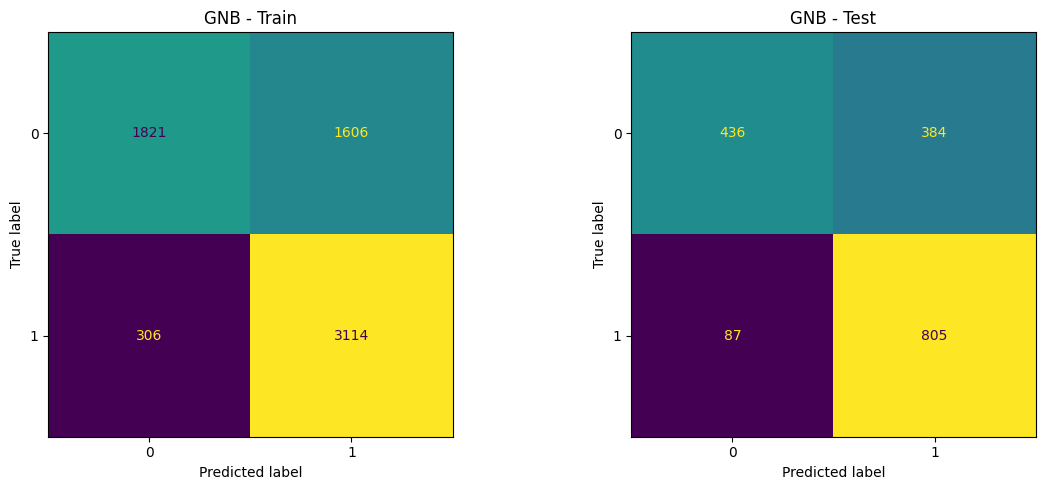

In [219]:
plot_confusion_matrices(gnb, "GNB", x_train, y_train, x_test, y_test)

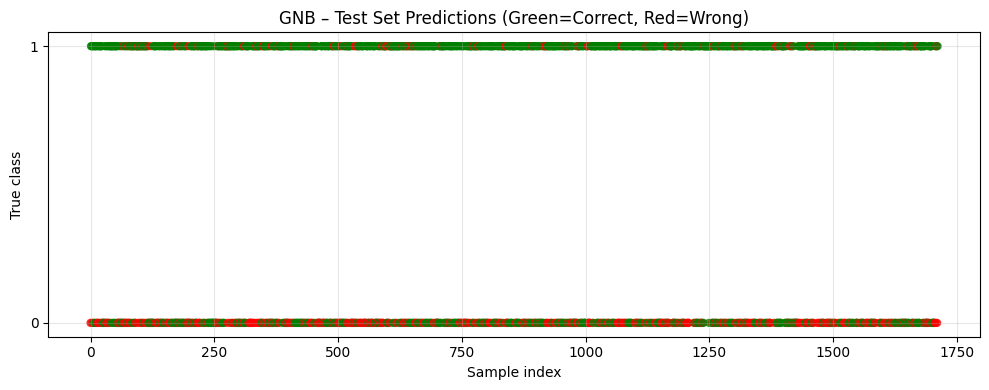

GNB Test Accuracy: 72.49%
Errors: 471 / 1712


In [220]:
correct = (y_pred_test_gnb == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("GNB – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"GNB Test Accuracy: {100*test_acc_gnb:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [221]:
evaluate_model_metrics(gnb, "GNB", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,83.37%,53.17%,64.93%,82000.00%
1,67.70%,90.25%,77.37%,89200.00%
accuracy,72.49%,72.49%,72.49%,72.49%


#### roc curve

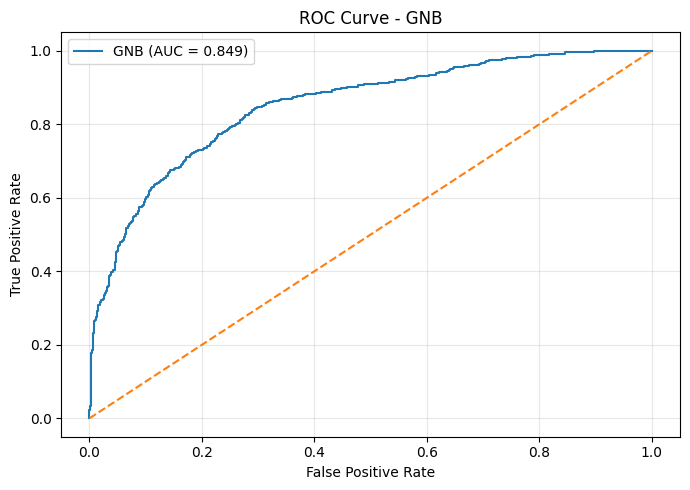

In [222]:
auc_val = plot_roc_curve(gnb, "GNB", x_test, y_test)

שמירה

In [223]:
results.append({
    "Model": "GNB",
    "Train Accuracy": train_acc_gnb,
    "Test Accuracy": test_acc_gnb
})

-----------------------------------------------------

### Decision Tree

#### בנייה

In [224]:
dt = DT(
    criterion='gini',
    max_depth=7,
    min_samples_leaf=87,
    min_samples_split=88,
    max_leaf_nodes=38
)

dt.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=7, max_leaf_nodes=38, min_samples_leaf=87,
                       min_samples_split=88)

#### דיוק אימון ומבחן

In [225]:
y_pred_train_dt = dt.predict(x_train)
train_acc_dt = accuracy_score(y_train, y_pred_train_dt)

y_pred_test_dt = dt.predict(x_test)
test_acc_dt = accuracy_score(y_test, y_pred_test_dt)

In [226]:
print("="*40)
print("BEST DT — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_dt*100:.2f}%")
print("="*40)

print("="*40)
print("BEST DT — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_dt*100:.2f}%")
print("="*40)

BEST DT — TRAIN SET PERFORMANCE
Accuracy : 79.68%
BEST DT — TEST SET PERFORMANCE
Accuracy : 77.80%


#### Confusion matrix

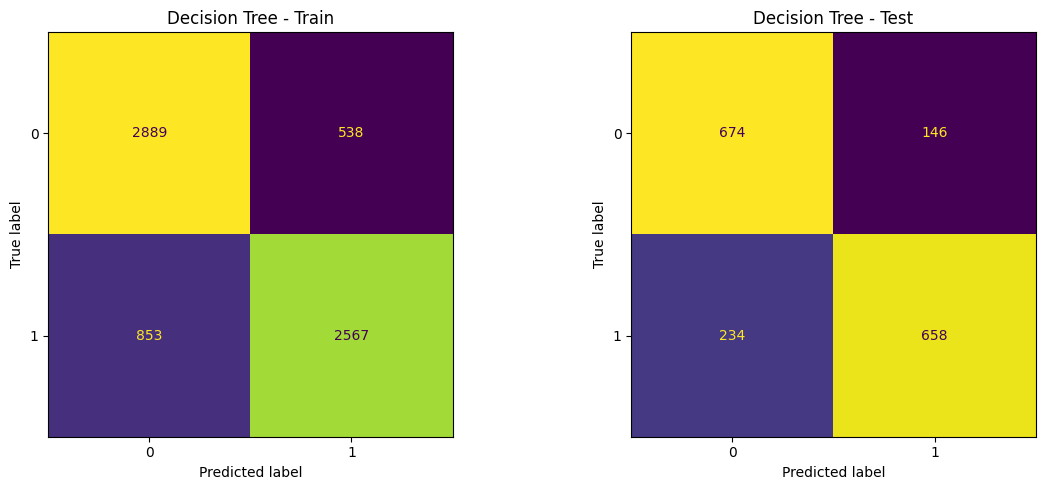

In [227]:
plot_confusion_matrices(dt, "Decision Tree", x_train, y_train, x_test, y_test)

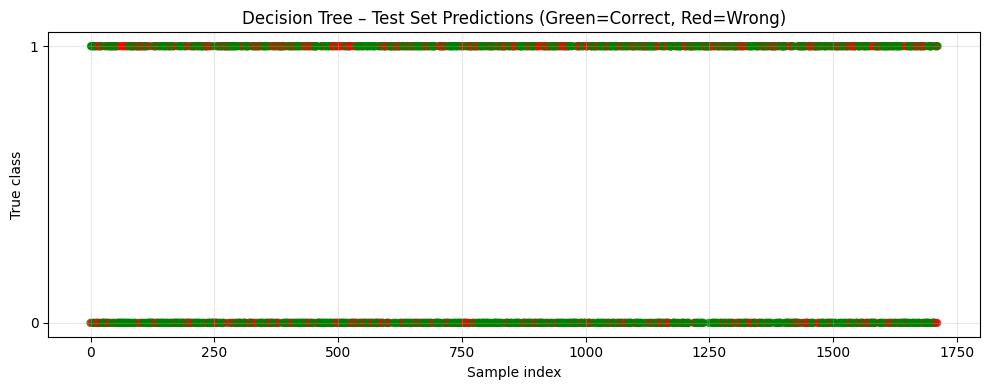

Decision Tree Test Accuracy: 77.80%
Errors: 380 / 1712


In [228]:
correct = (y_pred_test_dt == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("Decision Tree – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Decision Tree Test Accuracy: {100*test_acc_dt:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [229]:
evaluate_model_metrics(dt, "Decision Tree", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,74.23%,82.20%,78.01%,82000.00%
1,81.84%,73.77%,77.59%,89200.00%
accuracy,77.80%,77.80%,77.80%,77.80%


#### roc curve

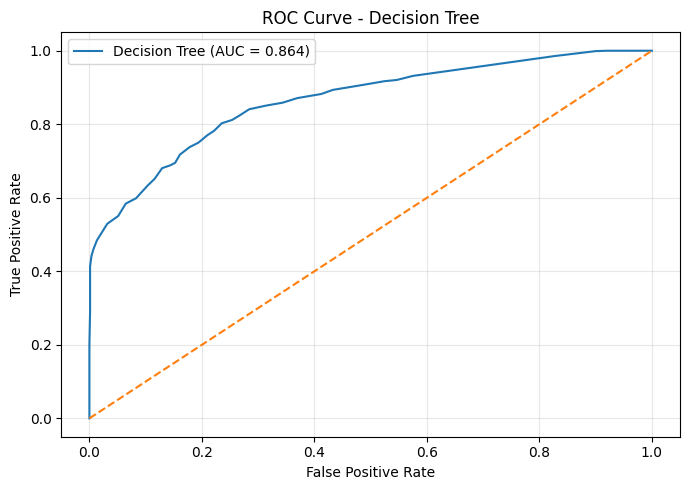

In [230]:
auc_val = plot_roc_curve(dt, "Decision Tree", x_test, y_test)

שמירה

In [231]:
results.append({
    "Model": "Decision Tree",
    "Train Accuracy": train_acc_dt,
    "Test Accuracy": test_acc_dt
})

----------------------------------

### Random Forest

#### בנייה

In [232]:
rf = RFC(
    n_estimators=250,
    random_state=42,
    max_depth=21,
    max_features='sqrt',
    min_samples_leaf=7
)
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=21, min_samples_leaf=7, n_estimators=250,
                       random_state=42)

#### דיוק אימון ומבחן

In [233]:
y_pred_train_rf = rf.predict(x_train)
train_acc_rf = accuracy_score(y_train, y_pred_train_rf)

y_pred_test_rf = rf.predict(x_test)
test_acc_rf = accuracy_score(y_test, y_pred_test_rf)

In [234]:
print("="*40)
print("BEST RF — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_rf*100:.2f}%")
print("="*40)

print("="*40)
print("BEST RF — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_rf*100:.2f}%")
print("="*40)

BEST RF — TRAIN SET PERFORMANCE
Accuracy : 87.62%
BEST RF — TEST SET PERFORMANCE
Accuracy : 80.02%


#### Confusion matrix

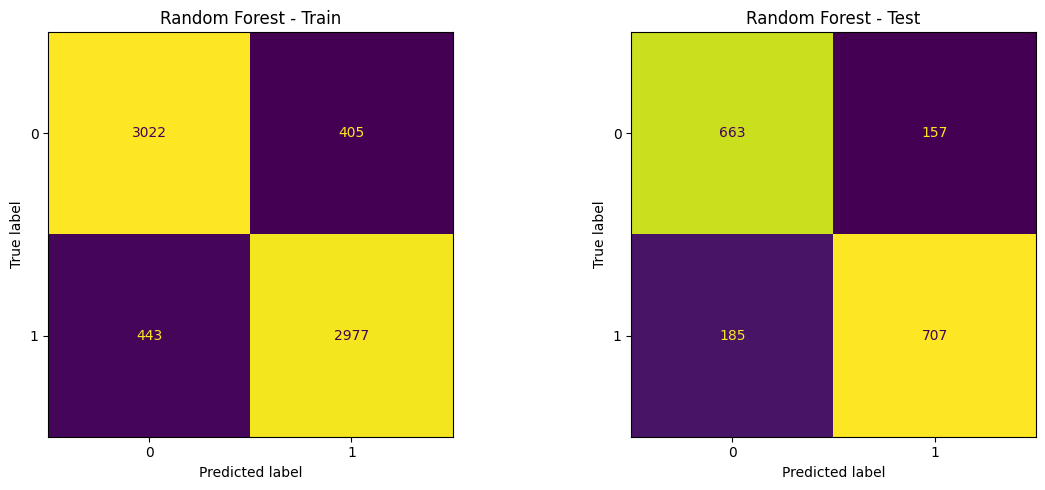

In [235]:
plot_confusion_matrices(rf, "Random Forest", x_train, y_train, x_test, y_test)

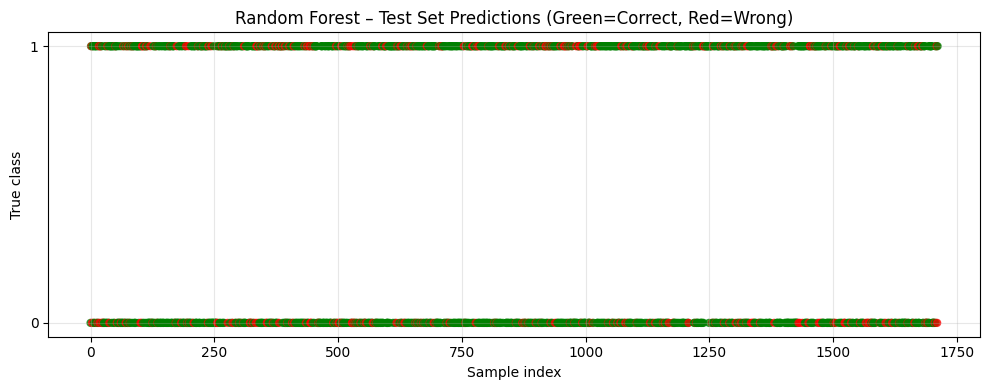

Random Forest Test Accuracy: 80.02%
Errors: 342 / 1712


In [236]:
correct = (y_pred_test_rf == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("Random Forest – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Random Forest Test Accuracy: {100*test_acc_rf:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [237]:
evaluate_model_metrics(rf, "Random Forest", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,78.18%,80.85%,79.50%,82000.00%
1,81.83%,79.26%,80.52%,89200.00%
accuracy,80.02%,80.02%,80.02%,80.02%


#### roc curve

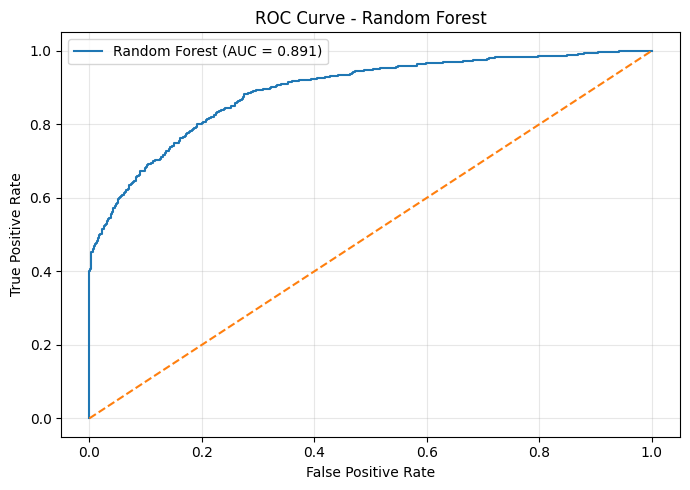

In [238]:
auc_val = plot_roc_curve(rf, "Random Forest", x_test, y_test)

שמירה

In [239]:
results.append({
    "Model": "Random Forest",
    "Train Accuracy": train_acc_rf,
    "Test Accuracy": test_acc_rf
})

--------------------------


### SVM

#### בנייה

In [240]:
svm = SVC(
    kernel='poly',
    C=1000,
    degree=2,
    random_state=42
)
svm.fit(x_train, y_train)

SVC(C=1000, degree=2, kernel='poly', random_state=42)

#### דיוק אימון ומבחן

In [241]:
y_pred_train_svm = svm.predict(x_train)
train_acc_svm = accuracy_score(y_train, y_pred_train_svm)

y_pred_test_svm = svm.predict(x_test)
test_acc_svm = accuracy_score(y_test, y_pred_test_svm)

In [242]:
print("="*40)
print("BEST SVM — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_svm*100:.2f}%")
print("="*40)

print("="*40)
print("BEST SVM — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_svm*100:.2f}%")
print("="*40)

BEST SVM — TRAIN SET PERFORMANCE
Accuracy : 80.96%
BEST SVM — TEST SET PERFORMANCE
Accuracy : 79.26%


#### Confusion matrix

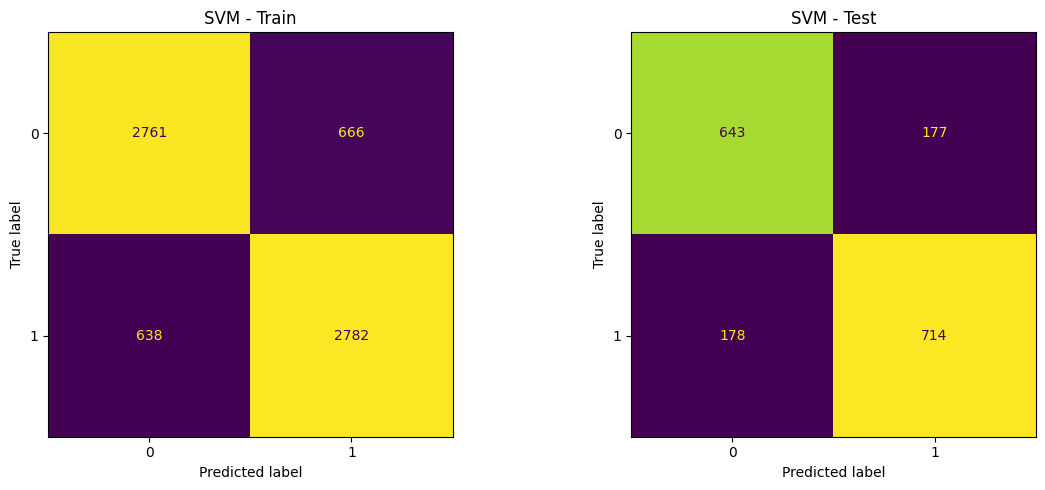

In [243]:
plot_confusion_matrices(svm, "SVM", x_train, y_train, x_test, y_test)

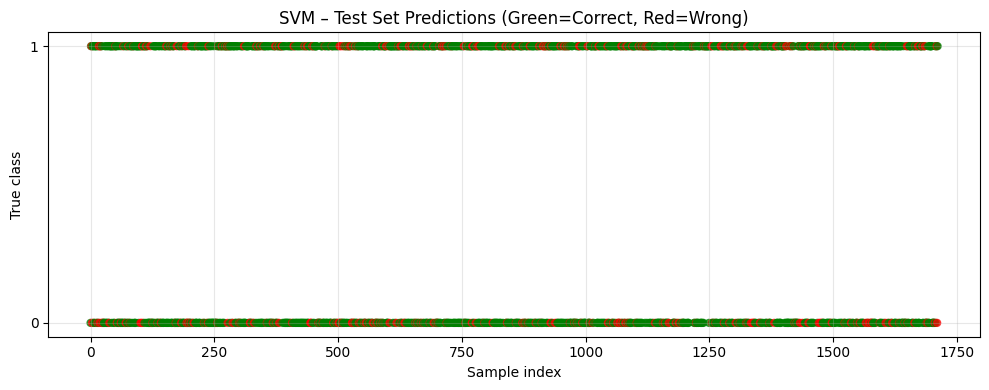

SVM Test Accuracy: 79.26%
Errors: 355 / 1712


In [244]:
correct = (y_pred_test_svm == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("SVM – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"SVM Test Accuracy: {100*test_acc_svm:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [245]:
evaluate_model_metrics(svm, "SVM", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,78.32%,78.41%,78.37%,82000.00%
1,80.13%,80.04%,80.09%,89200.00%
accuracy,79.26%,79.26%,79.26%,79.26%


#### roc curve

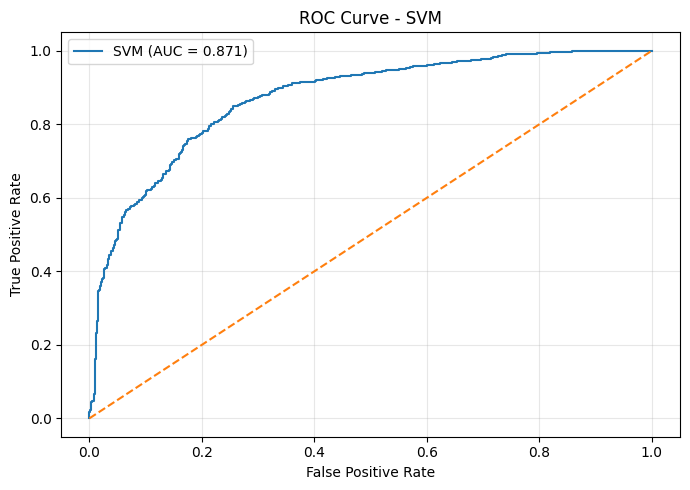

In [246]:
auc_val = plot_roc_curve(svm, "SVM", x_test, y_test)

שמירה

In [247]:
results.append({
    "Model": "SVM",
    "Train Accuracy": train_acc_svm,
    "Test Accuracy": test_acc_svm
})

-------------------------------------------

### Logistic Regression

#### בנייה

In [248]:
lr = LogisticRegression(
    penalty='l1',
    C=10,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

lr.fit(x_train, y_train)

LogisticRegression(C=10, max_iter=5000, penalty='l1', random_state=42,
                   solver='liblinear')

#### דיוק אימון ומבחן

In [249]:
y_pred_train_lr = lr.predict(x_train)
train_acc_lr = accuracy_score(y_train, y_pred_train_lr)

y_pred_test_lr = lr.predict(x_test)
test_acc_lr = accuracy_score(y_test, y_pred_test_lr)

In [250]:
print("="*40)
print("BEST LR — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_lr*100:.2f}%")
print("="*40)

print("="*40)
print("BEST LR — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_lr*100:.2f}%")
print("="*40)

BEST LR — TRAIN SET PERFORMANCE
Accuracy : 79.29%
BEST LR — TEST SET PERFORMANCE
Accuracy : 79.32%


#### Confusion matrix

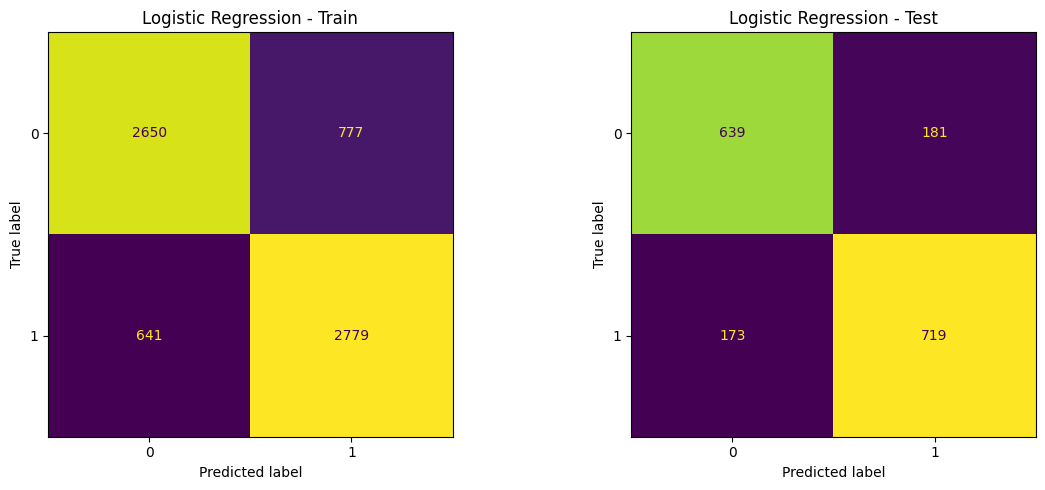

In [251]:
plot_confusion_matrices(lr, "Logistic Regression", x_train, y_train, x_test, y_test)

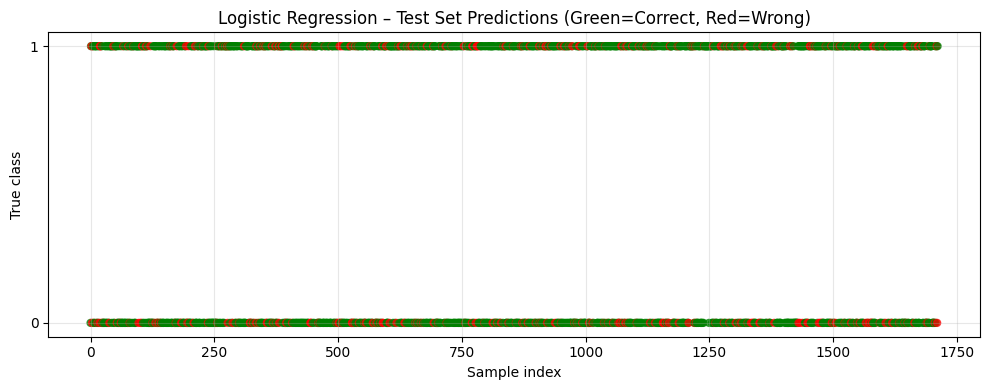

Logistic Regression Test Accuracy: 79.32%
Errors: 354 / 1712


In [252]:
correct = (y_pred_test_lr == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("Logistic Regression – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Logistic Regression Test Accuracy: {100*test_acc_lr:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [253]:
evaluate_model_metrics(lr, "Logistic Regression", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,78.69%,77.93%,78.31%,82000.00%
1,79.89%,80.61%,80.25%,89200.00%
accuracy,79.32%,79.32%,79.32%,79.32%


#### roc curve

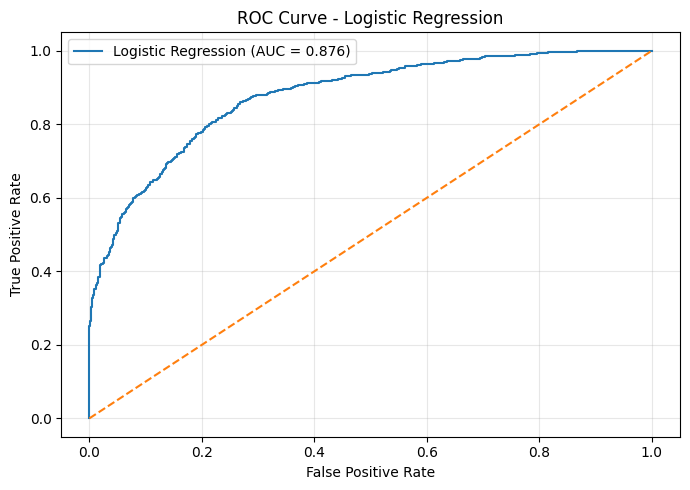

In [254]:
auc_val = plot_roc_curve(lr, "Logistic Regression", x_test, y_test)

שמירה

In [255]:
results.append({
    "Model": "Logistic Regression",
    "Train Accuracy": train_acc_lr,
    "Test Accuracy": test_acc_lr
})

---------------------------------

### MLP

#### בנייה

In [256]:


mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    alpha=0.01,
    activation="tanh",
    max_iter=5000,
    random_state=42
)
mlp.fit(x_train, y_train)

MLPClassifier(activation='tanh', alpha=0.01, hidden_layer_sizes=(128, 64),
              max_iter=5000, random_state=42)

#### דיוק אימון ומבחן

In [257]:
y_pred_train_mlp = mlp.predict(x_train)
train_acc_mlp = accuracy_score(y_train, y_pred_train_mlp)

y_pred_test_mlp = mlp.predict(x_test)
test_acc_mlp = accuracy_score(y_test, y_pred_test_mlp)

In [258]:
print("="*40)
print("BEST MLP — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_mlp*100:.2f}%")
print("="*40)

print("="*40)
print("BEST MLP — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_mlp*100:.2f}%")
print("="*40)

BEST MLP — TRAIN SET PERFORMANCE
Accuracy : 97.59%
BEST MLP — TEST SET PERFORMANCE
Accuracy : 77.04%


#### Confusion matrix

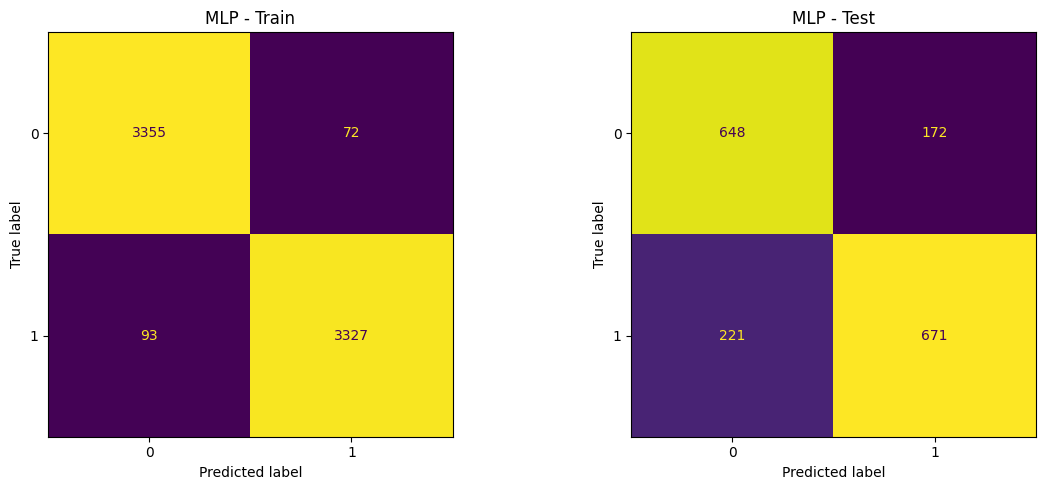

In [259]:
plot_confusion_matrices(mlp, "MLP", x_train, y_train, x_test, y_test)

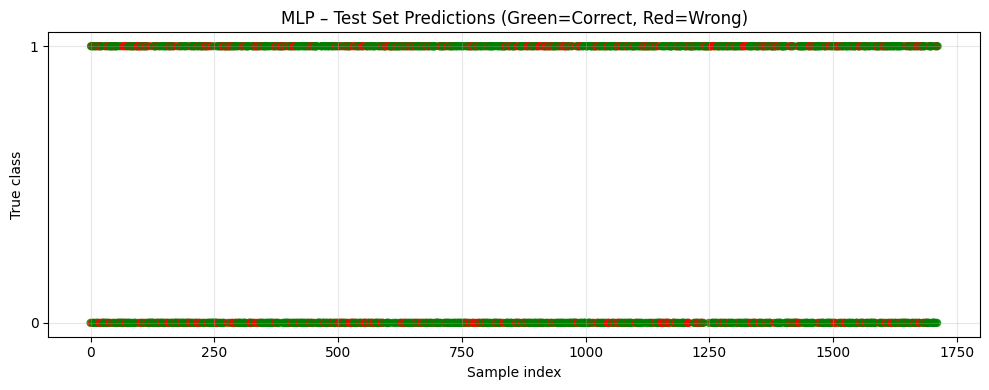

MLP Test Accuracy: 77.04%
Errors: 393 / 1712


In [260]:
correct = (y_pred_test_mlp == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("MLP – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MLP Test Accuracy: {100*test_acc_mlp:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [261]:
evaluate_model_metrics(mlp, "MLP", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,74.57%,79.02%,76.73%,82000.00%
1,79.60%,75.22%,77.35%,89200.00%
accuracy,77.04%,77.04%,77.04%,77.04%


#### roc curve

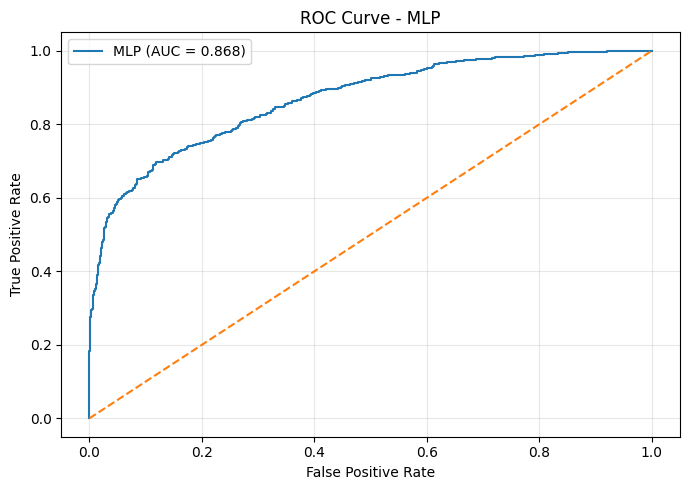

In [262]:
auc_val = plot_roc_curve(mlp, "MLP", x_test, y_test)

שמירה

In [263]:
results.append({
    "Model": "MLP",
    "Train Accuracy": train_acc_mlp,
    "Test Accuracy": test_acc_mlp
})

---------------------

### xgboost

#### בנייה

In [264]:
best_xgb_params = {
    "max_depth": 5,
    "n_estimators": 150,
    "learning_rate": 0.1
}
xgb = XGBClassifier(**best_xgb_params, random_state=42)
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

#### דיוק אימון ומבחן

In [265]:
y_pred_train_xgb = xgb.predict(x_train)
train_acc_xgb = accuracy_score(y_train, y_pred_train_xgb)

y_pred_test_xgb = xgb.predict(x_test)
test_acc_xgb = accuracy_score(y_test, y_pred_test_xgb)

In [266]:
print("="*40)
print("BEST XGB — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_xgb*100:.2f}%")
print("="*40)

print("="*40)
print("BEST XGB — TEST SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {test_acc_xgb*100:.2f}%")
print("="*40)

BEST XGB — TRAIN SET PERFORMANCE
Accuracy : 87.64%
BEST XGB — TEST SET PERFORMANCE
Accuracy : 80.96%


#### Confusion matrix

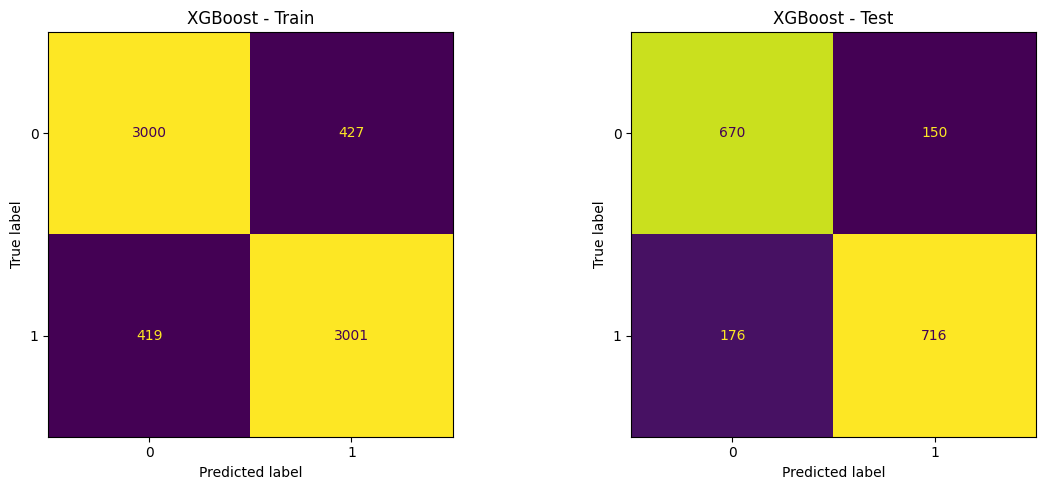

In [267]:
plot_confusion_matrices(xgb, "XGBoost", x_train, y_train, x_test, y_test)

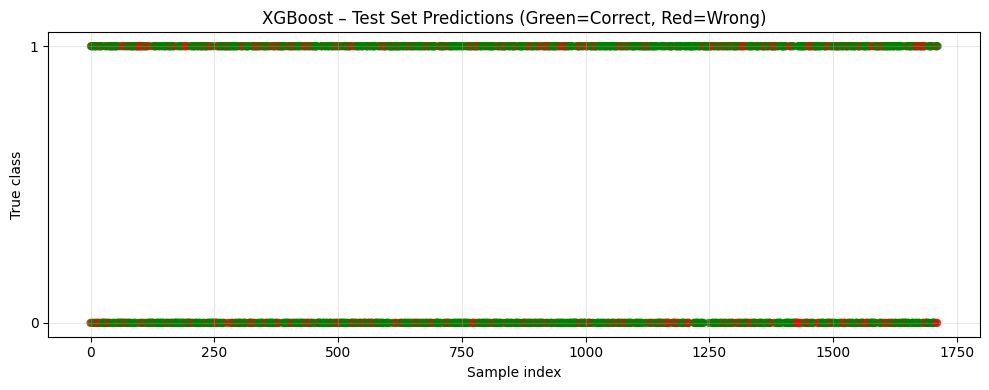

XGBoost Test Accuracy: 80.96%
Errors: 326 / 1712


In [268]:
correct = (y_pred_test_xgb == y_test)

# צבעים: ירוק = נכון, אדום = שגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_test)), y_test, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")
plt.ylabel("True class")
plt.title("XGBoost – Test Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"XGBoost Test Accuracy: {100*test_acc_xgb:.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

####  accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [269]:
evaluate_model_metrics(xgb, "XGBoost", x_train, y_train, x_test, y_test)

,precision,recall,f1-score,support
0,79.20%,81.71%,80.43%,82000.00%
1,82.68%,80.27%,81.46%,89200.00%
accuracy,80.96%,80.96%,80.96%,80.96%


#### roc curve

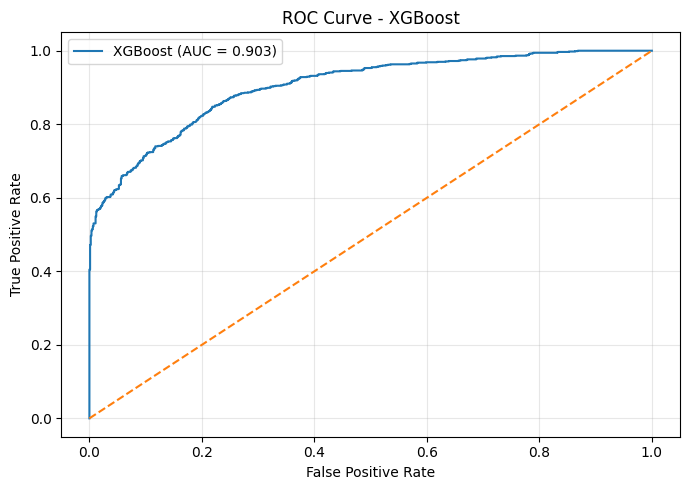

In [275]:
auc_val = plot_roc_curve(xgb, "XGBoost", x_test, y_test)

שמירה

In [271]:
results.append({
    "Model": "XGBoost",
    "Train Accuracy": train_acc_xgb,
    "Test Accuracy": test_acc_xgb
})

--------------------------------------

### השוואה סופית

In [272]:
results_df = pd.DataFrame(results).copy()

sort_col = "Test Accuracy" if "Test Accuracy" in results_df.columns else results_df.columns[1]
results_df = results_df.sort_values(sort_col, ascending=False).reset_index(drop=True)

display(
    results_df.style
        .hide(axis="index")
        .format("{:.2%}", subset=[c for c in results_df.columns if c != "Model"])
        .set_caption("Model Comparison (Train/Test Accuracy)")
)

Model,Train Accuracy,Test Accuracy
XGBoost,87.64%,80.96%
Random Forest,87.62%,80.02%
Logistic Regression,79.29%,79.32%
SVM,80.96%,79.26%
Decision Tree,79.68%,77.80%
KNN,79.16%,77.63%
MLP,97.59%,77.04%
LDA,76.92%,76.64%
QDA,76.57%,76.52%
GNB,72.08%,72.49%


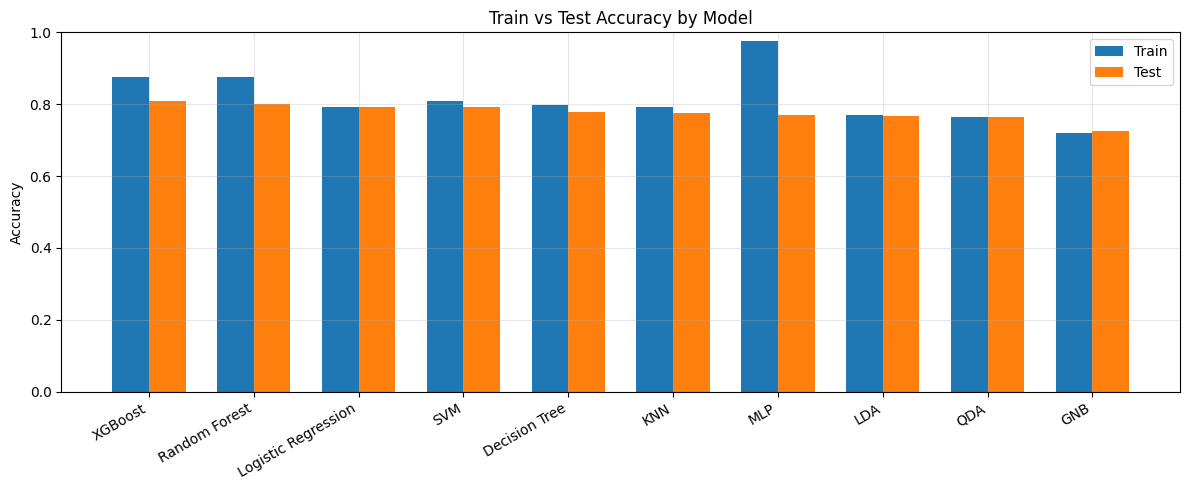

In [273]:
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(12,5))
plt.bar(x - width/2, results_df["Train Accuracy"], width, label="Train")
plt.bar(x + width/2, results_df["Test Accuracy"],  width, label="Test")

plt.xticks(x, results_df["Model"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by Model")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

השוואת גרפי roc

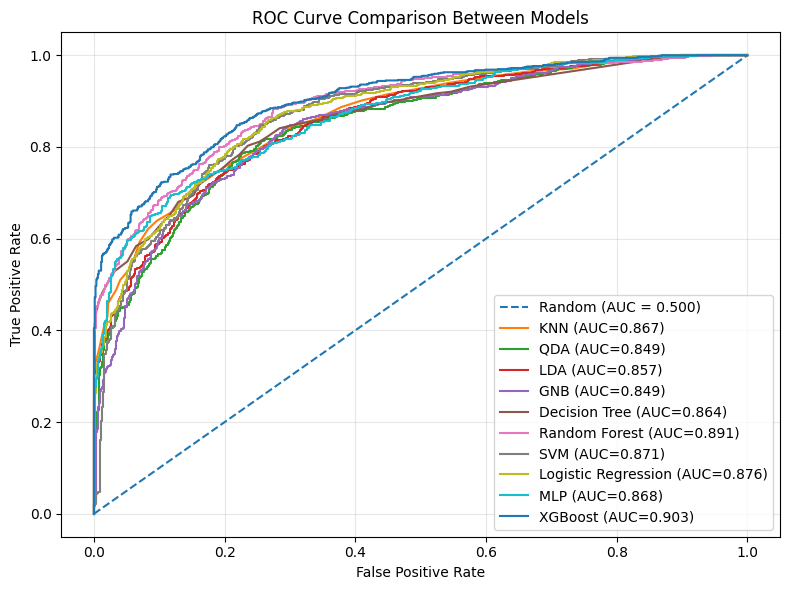

In [280]:
plt.figure(figsize=(8,6))

# baseline
plt.plot([0, 1], [0, 1], "--", label="Random (AUC = 0.500)")

models = {
    "KNN": knn,
    "QDA": qda,
    "LDA": lda,
    "GNB": gnb,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "Logistic Regression": lr,
    "MLP": mlp,
    "XGBoost": xgb
}

for r in results:
    name = r["Model"]
    model = models[name]

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.title("ROC Curve Comparison Between Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


----------------------------

הצגת חשיבות של כל תכונה

,feature,importance
15,HomePlanet_0.0,0.212128
8,TotalSpend,0.170108
0,CryoSleep,0.162630
16,HomePlanet_1.0,0.045105
4,FoodCourt,0.042841
5,ShoppingMall,0.042487
13,RoomSide,0.038339
6,Spa,0.035864
11,Deck,0.030750
7,VRDeck,0.029991


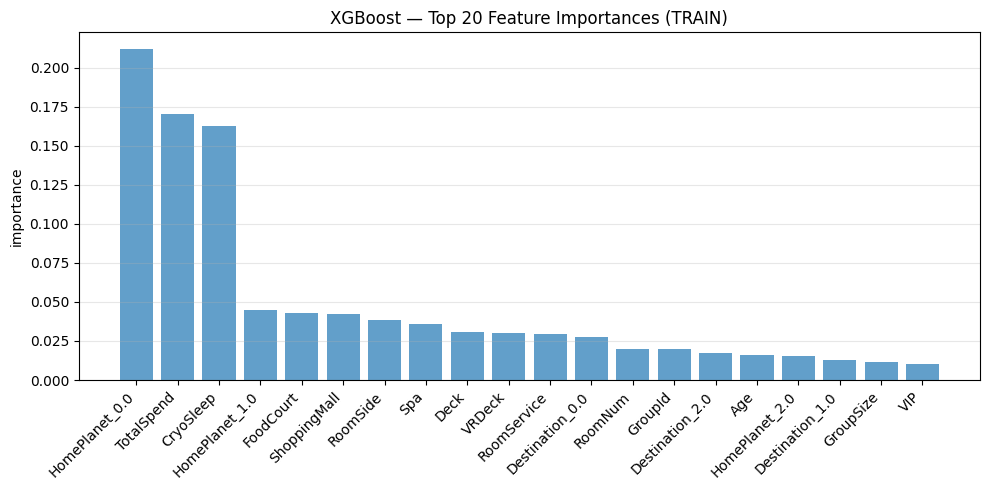

In [283]:
feature_names = x_copy.columns.tolist()
importances = xgb.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi_df.head(20))

x = np.arange(len(fi_df.head(20)))
plt.figure(figsize=(10,5))
plt.bar(x, fi_df.head(20)["importance"], alpha=0.7)
plt.xticks(x, fi_df.head(20)["feature"], rotation=45, ha="right")
plt.title("XGBoost — Top 20 Feature Importances (TRAIN)")
plt.ylabel("importance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

HomePlanet_0

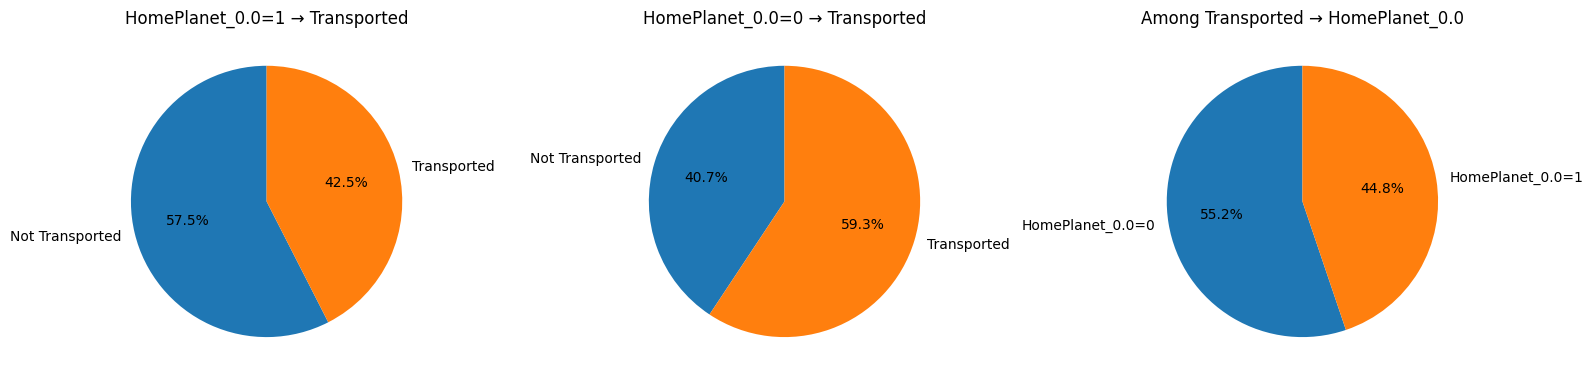

In [288]:
plot_feature_transport_pies(spaceship_data, "HomePlanet_0.0")

CryoSleep

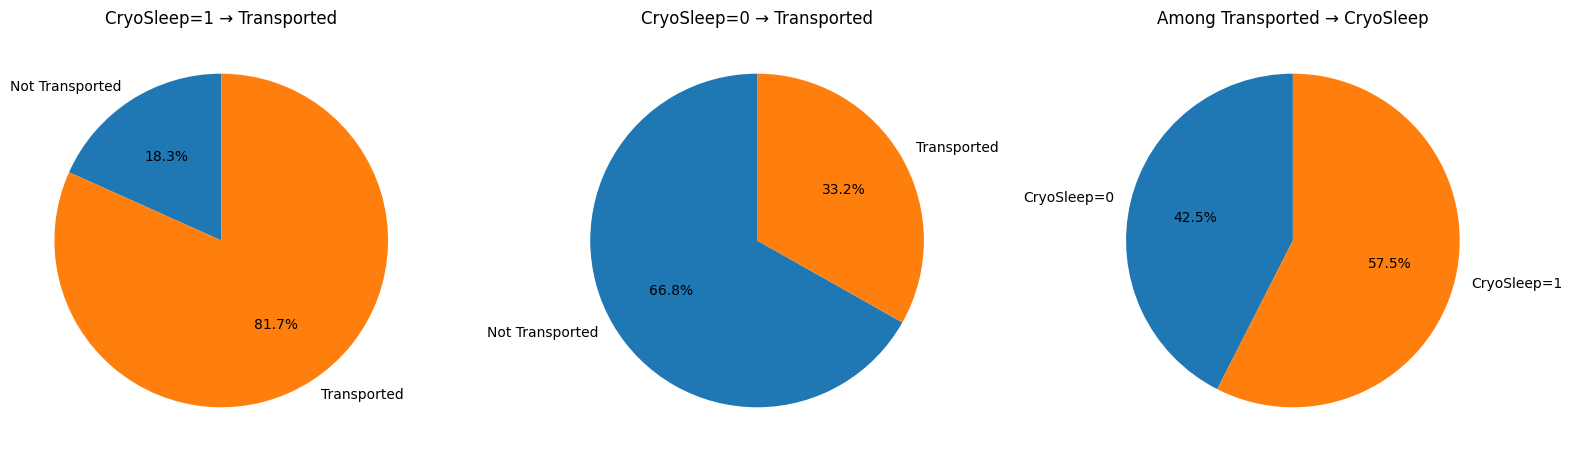

In [289]:
plot_feature_transport_pies(spaceship_data, "CryoSleep")


TotalSpend

C:\Users\Liad M\AppData\Local\Temp\ipykernel_43036\1771678526.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


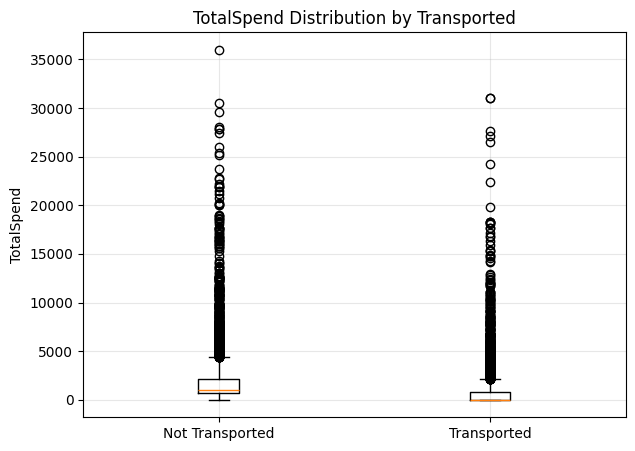

In [290]:
plt.figure(figsize=(7,5))

plt.boxplot(
    [
        spaceship_data[spaceship_data["Transported"] == 0]["TotalSpend"].dropna(),
        spaceship_data[spaceship_data["Transported"] == 1]["TotalSpend"].dropna()
    ],
    labels=["Not Transported", "Transported"]
)

plt.ylabel("TotalSpend")
plt.title("TotalSpend Distribution by Transported")
plt.grid(alpha=0.3)
plt.show()


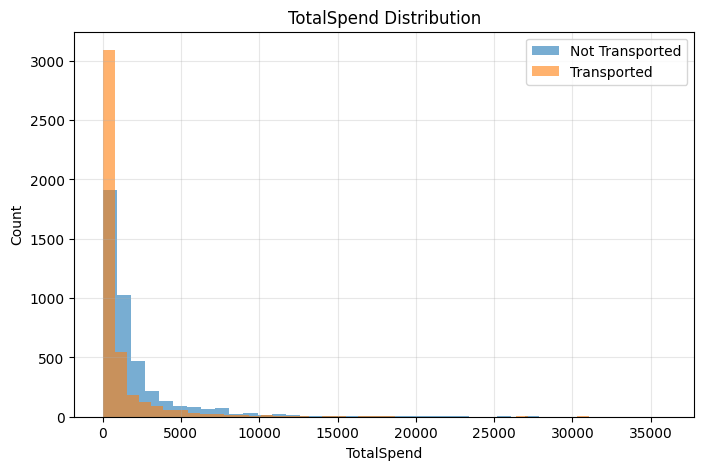

In [291]:
plt.figure(figsize=(8,5))

plt.hist(
    spaceship_data[spaceship_data["Transported"]==0]["TotalSpend"],
    bins=40,
    alpha=0.6,
    label="Not Transported"
)

plt.hist(
    spaceship_data[spaceship_data["Transported"]==1]["TotalSpend"],
    bins=40,
    alpha=0.6,
    label="Transported"
)

plt.xlabel("TotalSpend")
plt.ylabel("Count")
plt.title("TotalSpend Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
